In [1]:
!pip install langchain_groq
!pip install dotenv
!pip install langgraph
!pip install langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.7 MB/s eta 0:00:00


In [2]:
import os
os.environ['GROQ_API_KEY'] = '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'

In [3]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

# Load the model
llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.2) #1 is really creative
llmReasoning = ChatGroq(model_name="qwen/qwen3-32b", temperature=0.2)

In [44]:
from typing import TypedDict, List, Literal
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from pydantic import BaseModel, field_validator


class Step(BaseModel):
    number: int
    instruction:str
    duration: int

class Ingredient(BaseModel):
    ingredient_name: str
    amount: float
    metric_unit: str

class RecipeAnalysis(BaseModel):
    generic_name: str
    recipe_name: str
    variant: Literal["meat", "vegetarian", "vegan", "fish", "none"]
    difficulty: Literal["Easy", "Medium", "Intermediate"]
    total_time: int
    ingredients: List[Ingredient]
    steps: List[Step]

class RecipeCritique(BaseModel):
    strengths: List[str]
    weaknesses: List[str]
    open_questions: List[str]

# AgentState (what flows through the graph)

class AgentState(TypedDict, total=False):
    recipe_input: str
    analysis: RecipeAnalysis
    critique: RecipeCritique
    final_answer: RecipeAnalysis

In [51]:
recipe_analysis_prompt = """
You are a recipe analyst. Your only job is to extract everything from the recipe as-is.
Do not rewrite, improve, or judge anything — just collect the data.

### Recipe Input
{recipe_input}

### Extract the following
- generic_name: singular dish name only, no variants (e.g. "Pancake", "Lasagne")
- recipe_name: as descriptive as possible from the recipe title
- variant: based ONLY on ingredients — "meat", "vegetarian", "vegan", "fish", or "none"
- difficulty: based on prep steps only, NOT cooking time — "Easy", "Medium", or "Intermediate"
- total_time: exactly as stated in the recipe in minutes
- ingredients: extract name, amount, and unit exactly as written in the recipe
- steps: extract every step exactly as written, one action per step, with duration in minutes
  if mentioned, otherwise 0

### Output Format (JSON only, no extra text)
{{
  "generic_name": "...",
  "recipe_name": "...",
  "variant": "...",
  "difficulty": "...",
  "total_time": 0,
  "ingredients": [
    {{"ingredient_name": "...", "amount": 0.0, "metric_unit": "..."}}
  ],
  "steps": [
    {{"number": 1, "instruction": "...", "duration": 0}}
  ]
}}
"""

recipe_critique_prompt = """
You are a recipe quality checker. Review the analysis and fix the following things.

### Recipe Analysis
{analysis}

### Check and fix the following

**1. Steps — clarity and structure**
- Every step must be understandable by a 12-year-old
- If a step is unclear, rewrite it in simple language
  - BAD: "Combine the dry ingredients"
  - GOOD: "Add the flour, baking powder and salt into a large bowl and stir with a spoon"
- If a step contains multiple actions, flag it as a weakness — it should be split
  - BAD: "Mix the batter and pour into the tin and bake for 20 minutes"
  - GOOD: Split into 3 separate steps
- Always name specific ingredients, never say "the mixture" or "the ingredients"
- Explain any cooking jargon in plain language
  - BAD: "Fold in the egg whites"
  - GOOD: "Gently stir in the egg whites using a spatula in slow circular motions to keep it fluffy"

**2. Variant**
- Check if the variant matches the ingredient list
  - vegan: no animal products at all
  - vegetarian: dairy or eggs allowed, no meat/fish
  - meat: contains any meat or poultry
  - fish: contains any fish or seafood
  - none: does not fit any above

**3. Difficulty**
- Must reflect prep complexity only, NOT cooking time
  - Easy: few simple steps, no special technique
  - Medium: several steps or some technique
  - Intermediate: many steps, parallel actions, or advanced techniques

**4. Units**
- Expand shorthands to their full word, do not change the unit type:
  tsp → teaspoon (keep as teaspoon, do NOT convert to gram)
  tbsp / tbs → tablespoon (keep as tablespoon, do NOT convert to gram)
  g → gram, kg → kilogram, mg → milligram
  ml / mL → milliliter, l / L → liter

**5. Generic and variant name**
- Identify the generic dish name (e.g. "Pancake", "Lasagne") — singular, no variant info.
- Identify the specific recipe name — descriptive, no marketing words like "best" or "ultimate".

### Output Format (JSON only, no extra text)
{{
  "strengths": ["...", "..."],
  "weaknesses": ["...", "..."],
  "open_questions": ["...", "..."]
}}
"""

recipe_refinement_prompt = """
You are a recipe editor. Apply every fix flagged in the critique to produce the final version.
Preserve everything listed as a strength. Only change what the critique flags.

### Original Analysis
{analysis}

### Critique
{critique}

### Rules
- difficulty must be exactly "Easy", "Medium", or "Intermediate"
- variant must be exactly "meat", "vegetarian", "vegan", "fish", or "none"
- Every step must be one action only, clear to a 12-year-old
- Do NOT invent information not in the original analysis
- Expand ALL shorthands before finalising:
  tsp → teaspoon, tbsp → tablespoon, tbs → tablespoon
  g → gram, ml → milliliter, l → liter, kg → kilogram
- Identify the generic dish name (e.g. "Pancake", "Lasagne") — singular, no variant info.
- Identify the specific recipe name — descriptive, no marketing words like "best" or "ultimate".



### Output Format (JSON only, no extra text)
{{
  "generic_name": "...",
  "recipe_name": "...",
  "variant": "...",
  "difficulty": "...",
  "total_time": 0,
  "ingredients": [
    {{"ingredient_name": "...", "amount": 0.0, "metric_unit": "..."}}
  ],
  "steps": [
    {{"number": 1, "instruction": "...", "duration": 0}}
  ]
}}
"""

In [30]:
# -------------------------
# Node 1: Recipe Analyzer (LLM -> Pydantic)
# -------------------------
def recipe_analyzer(state: AgentState):
    """This node extracts structured recipe data from raw user input."""

    # Retrieve the recipe input from state
    recipe_input = state["recipe_input"]

    # Use structured output (pydantic class)
    structured_llm = llm.with_structured_output(RecipeAnalysis, method="json_mode")

    # Create a prompt
    prompt = recipe_analysis_prompt.format(
        recipe_input=recipe_input
    )

    # Invoke the llm and retrieve the analysis
    analysis = structured_llm.invoke(prompt)

    # Update the state
    return {
        "analysis": analysis
    }


# -------------------------
# Node 2: Recipe Critique (LLM -> Pydantic)
# -------------------------
def recipe_critique(state: AgentState):
    """This node checks the analysis for rule violations and quality issues."""

    # Retrieve the analysis from state
    analysis: RecipeAnalysis = state["analysis"]

    # Use structured output (pydantic class)
    structured_llm = llm.with_structured_output(RecipeCritique, method="json_mode")

    # Create a prompt
    prompt = recipe_critique_prompt.format(
        analysis=analysis.model_dump_json(indent=2)
    )

    # Invoke the llm and retrieve the critique
    critique = structured_llm.invoke(prompt)

    # Update the state
    return {
        "critique": critique
    }


# -------------------------
# Node 3: Recipe Refinement (LLM -> Pydantic)
# -------------------------
def recipe_refinement(state: AgentState):
    """This node produces a corrected final version of the recipe analysis."""

    # Retrieve the analysis and critique from state
    analysis: RecipeAnalysis = state["analysis"]
    critique: RecipeCritique = state["critique"]

    # Use structured output (pydantic class)
    structured_llm = llm.with_structured_output(RecipeAnalysis, method="json_mode")

    # Create a prompt
    prompt = recipe_refinement_prompt.format(
        analysis=analysis.model_dump_json(indent=2),
        critique=critique.model_dump_json(indent=2)
    )

    # Invoke the llm and retrieve the refined analysis
    final_answer = structured_llm.invoke(prompt)

    # Update the state
    return {
        "final_answer": final_answer
    }

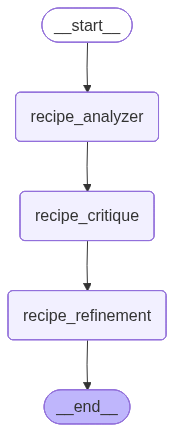

In [31]:
# -------------------------
# Build the graph
# -------------------------
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("recipe_analyzer", recipe_analyzer)
graph.add_node("recipe_critique", recipe_critique)
graph.add_node("recipe_refinement", recipe_refinement)

# Add edges
graph.add_edge(START, "recipe_analyzer")
graph.add_edge("recipe_analyzer", "recipe_critique")
graph.add_edge("recipe_critique", "recipe_refinement")
graph.add_edge("recipe_refinement", END)

# Compile
app = graph.compile()

# Visualization
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

Keto Brownies

https://gimmedelicious.com/worlds-best-keto-brownies/


In [52]:
recipe = input("Please enter your recipe: ")
result = app.invoke({"recipe_input": recipe})

# ---- EXTRACTED RECIPE (node 1 output) ----
analysis = result["analysis"]
print("=== EXTRACTED RECIPE ===")
print("RECIPE NAME:", analysis.recipe_name)
print("GENERIC NAME:", analysis.generic_name)
print("VARIANT:", analysis.variant)
print("DIFFICULTY:", analysis.difficulty)
print("TOTAL TIME:", analysis.total_time, "minutes")
print("\nINGREDIENTS:")
for i in analysis.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in analysis.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

# ---- CRITIQUE (node 2 output) ----
print("\n=== CRITIQUE ===")
print("Strengths:", result["critique"].strengths)
print("Weaknesses:", result["critique"].weaknesses)
print("Open Questions:", result["critique"].open_questions)

# ---- FINAL REFINED RECIPE (node 3 output) ----
final = result["final_answer"]
print("\n=== FINAL REFINED RECIPE ===")
print("RECIPE NAME:", final.recipe_name)
print("GENERIC NAME:", final.generic_name)
print("VARIANT:", final.variant)
print("DIFFICULTY:", final.difficulty)
print("TOTAL TIME:", final.total_time, "minutes")
print("\nINGREDIENTS:")
for i in final.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in final.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

Please enter your recipe: World’s Best Keto Brownies By Layla Atik  on Oct 17, 2018, Updated Sep 27, 2024  4.58 from 157 votes  Save Pin Share Jump to Recipe This post may contain affiliate links. Please read our disclosure policy.  Moist, chewy and fudgy on the inside with a crisp crinkle layer on the top making these the world’s BEST keto brownies. They’re rich and delicious and will satisfy your chocolate cravings with just 1 net carb per brownie!   I’m not exaggerating when I say these are the world’s best keto brownies because they certainly are. I’ve tested this recipe over a dozen times and made loads of batches until I finally found the BEST version. These brownies are super fudgy and moist and have a crispy outside layer that melts in your mouth. They’re so good my husband and kids had no idea they were keto and liked them much better than “regular” brownies.  If you’re like me and you have no self-control, I suggest only baking a small batch or give some away because I went t

Crack Chicken

(https://www.wholesomeyum.com/crock-pot-slow-cooker-crack-chicken-recipe/)

In [53]:
recipe = input("Please enter your recipe: ")
result = app.invoke({"recipe_input": recipe})

# ---- EXTRACTED RECIPE (node 1 output) ----
analysis = result["analysis"]
print("=== EXTRACTED RECIPE ===")
print("RECIPE NAME:", analysis.recipe_name)
print("GENERIC NAME:", analysis.generic_name)
print("VARIANT:", analysis.variant)
print("DIFFICULTY:", analysis.difficulty)
print("TOTAL TIME:", analysis.total_time, "minutes")
print("\nINGREDIENTS:")
for i in analysis.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in analysis.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

# ---- CRITIQUE (node 2 output) ----
print("\n=== CRITIQUE ===")
print("Strengths:", result["critique"].strengths)
print("Weaknesses:", result["critique"].weaknesses)
print("Open Questions:", result["critique"].open_questions)

# ---- FINAL REFINED RECIPE (node 3 output) ----
final = result["final_answer"]
print("\n=== FINAL REFINED RECIPE ===")
print("RECIPE NAME:", final.recipe_name)
print("GENERIC NAME:", final.generic_name)
print("VARIANT:", final.variant)
print("DIFFICULTY:", final.difficulty)
print("TOTAL TIME:", final.total_time, "minutes")
print("\nINGREDIENTS:")
for i in final.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in final.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

Please enter your recipe: Crack Chicken Make my easy crack chicken recipe in the Crock Pot with just 5 minutes of prep! It's creamy, cheesy, and so addicting for the whole family. Ingredients: •	2 lb Boneless skinless chicken breasts •	2 tbsp Dried parsley •	1 tbsp Dried dill •	1 tbsp Dried chives •	1 tsp Garlic powder •	1 tsp Onion powder •	1/2 tsp Black pepper (or more to taste) •	12 oz Cream cheese (cut into 3/4 inch pieces) •	1 cup Cheddar cheese (shredded; plus more for topping if you like) •	8 slices Cooked bacon (chopped or crumbled, or 1/2 cup bacon bits; plus more for topping) •	1/3 cup Green onions (sliced thinly; plus more for topping) Instructions 1.	Place the chicken breasts into a slow cooker in a single layer. Sprinkle dried herbs and spices on top. 2.	Arrange the pieces of cream cheese evenly over the chicken. 3.	Cook the chicken for 2-3 hours on high or 4-5 hours on low, until the chicken is easy to shred. 4.	Shred the chicken with two forks, and stir to mix with the c

Grilled lobster with lobster emulsion

https://www.greatbritishchefs.com/recipes/grilled-lobster-emulsion-recipe

In [54]:
recipe = input("Please enter your recipe: ")
result = app.invoke({"recipe_input": recipe})
result["final_answer"] = fix_units(result["final_answer"])

# ---- EXTRACTED RECIPE (node 1 output) ----
analysis = result["analysis"]
print("=== EXTRACTED RECIPE ===")
print("RECIPE NAME:", analysis.recipe_name)
print("GENERIC NAME:", analysis.generic_name)
print("VARIANT:", analysis.variant)
print("DIFFICULTY:", analysis.difficulty)
print("TOTAL TIME:", analysis.total_time, "minutes")
print("\nINGREDIENTS:")
for i in analysis.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in analysis.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

# ---- CRITIQUE (node 2 output) ----
print("\n=== CRITIQUE ===")
print("Strengths:", result["critique"].strengths)
print("Weaknesses:", result["critique"].weaknesses)
print("Open Questions:", result["critique"].open_questions)

# ---- FINAL REFINED RECIPE (node 3 output) ----
final = result["final_answer"]
print("\n=== FINAL REFINED RECIPE ===")
print("RECIPE NAME:", final.recipe_name)
print("GENERIC NAME:", final.generic_name)
print("VARIANT:", final.variant)
print("DIFFICULTY:", final.difficulty)
print("TOTAL TIME:", final.total_time, "minutes")
print("\nINGREDIENTS:")
for i in final.ingredients:
    print(f"  {i.amount} {i.metric_unit} {i.ingredient_name}")
print("\nSTEPS:")
for s in final.steps:
    if s.duration > 0:
        print(f"  {s.number}. {s.instruction} ({s.duration} min)")
    else:
        print(f"  {s.number}. {s.instruction}")

Please enter your recipe: Grilled lobster with lobster emulsion Ingredients Imperial For the lobster •	2 lobsters •	iced water •	130g of butter •	1/2 white onion, finely sliced •	2 tbsp of chervil •	salt and pepper For the lobster emulsion •	40g of fish stock •	15g of white soy sauce •	135g of butter, cut into small cubes •	40g of mayonnaise •	20g of lemon juice  Method 1 Place the lobster on a chopping board. Place the tip of a knife on the top of the lobster’s head, in the centre and in between the eyes. In one quick motion, drive the knife into the head until you reach the chopping board. Then, bring the knife down, cutting the head in half •	2 lobsters 2 Rotate the lobster 180 degrees and cut the tail in half, leaving the lobster intact 3 Remove the claws, then remove the intestine running down the lobster tail and discard it. Set the lobster tail half aside in the fridge until ready to serve 4 Using a spoon, remove the offal from the lobster head. Wipe the insides of the head to r